In [51]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

In [52]:
df = pd.read_csv('../data/lab05/q01.csv')

df.drop_duplicates()

X = df[['restecg', 'oldpeak']]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

results = {}
for scheme in ['hard', 'soft']:
  models = {
    'rf': RandomForestClassifier(random_state=0),
    'xg': XGBClassifier(random_state=0),
    'knn': KNeighborsClassifier(n_neighbors=5),
    'dt': DecisionTreeClassifier(random_state=0)
  }

  vc = VotingClassifier(estimators=list(models.items()), voting=scheme)

  vc.fit(X_train, y_train)
  results[scheme] = {
    'accuracy': vc.score(X_test, y_test),
    'vc': vc
  }

best_models = results[max(results, key=lambda k: results[k]['accuracy'])]

for name, model in best_models['vc'].named_estimators_.items():
  print(name)
  try:
    print(model.feature_importances_)
  except:
    print('No Feature Importances')

rf
[0.10032458 0.89967542]
xg
[0.30532113 0.6946789 ]
knn
No Feature Importances
dt
[0.11917688 0.88082312]


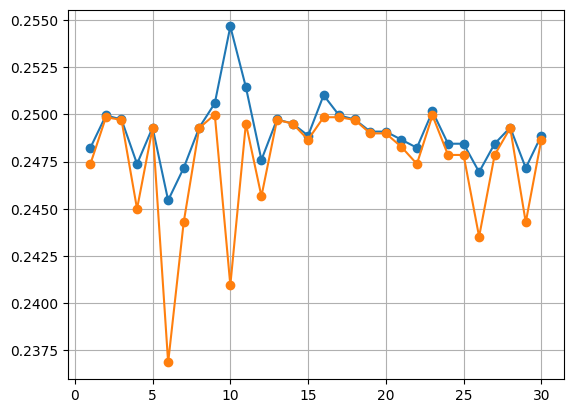

In [ ]:
from sklearn.utils import resample

biases, variances = [], []

for i in range(30):
    X_s, y_s = resample(X_train, y_train, random_state=i)
    
    vc.fit(X_s, y_s)
    preds = vc.predict(X_test)

    bias = np.mean((preds - np.mean(y_test))**2)
    variance = np.var(preds)
    
    biases.append(bias)
    variances.append(variance)

plt.plot(range(1, 31), biases, marker='o')
plt.plot(range(1, 31), variances, marker='o')
plt.grid(True)
plt.show()
